# Genel Bitki Hastaligi Tanima Modeli

**Yaklasim:** Turden bagimsiz (species-independent) 10 sinifli hastalık tespiti  
**Veri:** PlantVillage + PlantDoc + PlantPathology2021 + Cassava + Rice  
**Model:** EfficientNetB3 (transfer learning, 3 asamali fine-tuning)  
**Cikti:** TFLite modeli (mobil uygulama icin)


In [1]:
# Ne: Bellek yonetimi - MKL limitlerini ayarla
# Neden: CPU egitiminde MKL cok fazla RAM tuketiyor; bu ayarlar bellek hatasi olusmasini onler
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_MKL_ALLOC_MAX_BYTES'] = '1073741824'  # 1GB MKL limiti

# Ne: GPU varligini kontrol et
# Neden: Kaggle GPU T4 x2 ile egitim cok daha hizli; local CPU ile sadece kucuk test yapilir

import tensorflow as tf
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU bulundu: {len(gpus)} adet')
    for g in gpus: print(' ', g)
else:
    print('GPU yok - CPU ile calisiliyor (egitim icin Kaggle kullan)')


TensorFlow: 2.21.0
GPU yok - CPU ile calisiliyor (egitim icin Kaggle kullan)


In [2]:
# Ne: Kutuphaneleri import et
# Neden: Importlari ayri hucrede tutmak, egitim hucrelerini bagimsiz yeniden calistirmaya izin verir

import os, json, shutil, random, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

warnings.filterwarnings("ignore")
print("Kutuphaneler yuklendi.")
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


Kutuphaneler yuklendi.
TensorFlow: 2.21.0
GPU: []


In [3]:
# Ne: Calisma ortamini belirle, tum path ve hiperparametreleri tanimla
# Neden: Tum ayarlar tek hucrede; kolayca degistirilebilir

_cwd = Path.cwd().resolve()
if (_cwd / "requirements.txt").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "requirements.txt").exists():
    PROJECT_ROOT = _cwd.parent
elif (_cwd / "data").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "data").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd

DATA_DIR    = PROJECT_ROOT / "data"
RAW_DIR     = DATA_DIR / "raw"
MODELS_DIR  = PROJECT_ROOT / "models"
NAMES_DIR   = PROJECT_ROOT / "class_names"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
for d in [MODELS_DIR, NAMES_DIR, OUTPUTS_DIR]:
    d.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)

PV_TRAIN_DIR = RAW_DIR / "plantvillage" / "dataset" / "New Plant Diseases Dataset(Augmented)" / "train"
PDOC_DIR     = RAW_DIR / "plantdoc"
PP21_DIR     = RAW_DIR / "plant_pathology_2021"
CASSAVA_DIR  = RAW_DIR / "cassava"
RICE_DIR     = RAW_DIR / "rice"

# 7 sinifli model icin ayri klasorler (10 sinifli veri bozulmasin)
COMBINED_DIR  = DATA_DIR / "combined_disease_7class"
SPLIT_DIR     = DATA_DIR / "disease_split_7class"
MODEL_PATH    = str(MODELS_DIR / "best_disease_model_7class.keras")
MODEL_STAGE1  = str(MODELS_DIR / "disease_model_7class_stage1.keras")
TFLITE_PATH   = str(MODELS_DIR / "plant_disease_model_7class.tflite")
LABEL_PATH    = str(NAMES_DIR / "disease_class_names_7class.json")

IMG_SIZE    = (300, 300)
BATCH_SIZE  = 32
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

EPOCHS_HEAD = 12
EPOCHS_FIN1 = 25
EPOCHS_FIN2 = 20

# 7 sinif: bacterial+blight+viral+leaf_spot -> leaf_disease birlestirme
DISEASE_CLASSES = sorted(["healthy", "leaf_disease", "mold",
                           "pest_damage", "powdery_mildew", "rot", "rust"])
NUM_CLASSES  = len(DISEASE_CLASSES)
VALID_EXT    = {".jpg", ".jpeg", ".png", ".webp"}

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f"Sinif sayisi: {NUM_CLASSES} -> {DISEASE_CLASSES}")
print(f"IMG_SIZE: {IMG_SIZE}, BATCH_SIZE: {BATCH_SIZE}")

PROJECT_ROOT: C:\Users\HP\Desktop\plant_project_hastalık\plant_project
Sinif sayisi: 7 -> ['healthy', 'leaf_disease', 'mold', 'pest_damage', 'powdery_mildew', 'rot', 'rust']
IMG_SIZE: (300, 300), BATCH_SIZE: 32


In [4]:
# Ne: Her dataset icin orijinal etiket -> 7 genel hastalik kategorisi
# Neden: bacterial,blight,viral,leaf_spot gorsel olarak ayirt edilemez;
#        leaf_disease altinda birlestiriliyor

PV_MAP = {
    "Apple___Apple_scab":                         "leaf_disease",
    "Apple___Black_rot":                           "rot",
    "Apple___Cedar_apple_rust":                    "rust",
    "Apple___healthy":                             "healthy",
    "Blueberry___healthy":                         "healthy",
    "Cherry_(including_sour)___Powdery_mildew":    "powdery_mildew",
    "Cherry_(including_sour)___healthy":           "healthy",
    "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot": "leaf_disease",
    "Corn_(maize)___Common_rust_":                 "rust",
    "Corn_(maize)___Northern_Leaf_Blight":         "leaf_disease",
    "Corn_(maize)___healthy":                      "healthy",
    "Grape___Black_rot":                           "rot",
    "Grape___Esca_(Black_Measles)":                "leaf_disease",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)":  "leaf_disease",
    "Grape___healthy":                             "healthy",
    "Orange___Haunglongbing_(Citrus_greening)":    "leaf_disease",
    "Peach___Bacterial_spot":                      "leaf_disease",
    "Peach___healthy":                             "healthy",
    "Pepper,_bell___Bacterial_spot":               "leaf_disease",
    "Pepper,_bell___healthy":                      "healthy",
    "Potato___Early_blight":                       "leaf_disease",
    "Potato___Late_blight":                        "leaf_disease",
    "Potato___healthy":                            "healthy",
    "Raspberry___healthy":                         "healthy",
    "Soybean___healthy":                           "healthy",
    "Squash___Powdery_mildew":                     "powdery_mildew",
    "Strawberry___Leaf_scorch":                    "leaf_disease",
    "Strawberry___healthy":                        "healthy",
    "Tomato___Bacterial_spot":                     "leaf_disease",
    "Tomato___Early_blight":                       "leaf_disease",
    "Tomato___Late_blight":                        "leaf_disease",
    "Tomato___Leaf_Mold":                          "mold",
    "Tomato___Septoria_leaf_spot":                 "leaf_disease",
    "Tomato___Spider_mites Two-spotted_spider_mite": "pest_damage",
    "Tomato___Target_Spot":                        "leaf_disease",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus":      "leaf_disease",
    "Tomato___Tomato_mosaic_virus":                "leaf_disease",
    "Tomato___healthy":                            "healthy",
}

PDOC_MAP = {
    "Apple Scab Leaf":            "leaf_disease",
    "Apple leaf":                 "healthy",
    "Apple rust leaf":            "rust",
    "Bell_pepper leaf":           "healthy",
    "Bell_pepper leaf spot":      "leaf_disease",
    "Blueberry leaf":             "healthy",
    "Cherry leaf":                "healthy",
    "Corn Gray leaf spot":        "leaf_disease",
    "Corn leaf blight":           "leaf_disease",
    "Corn rust leaf":             "rust",
    "Peach leaf":                 "healthy",
    "Potato leaf":                "healthy",
    "Potato leaf early blight":   "leaf_disease",
    "Potato leaf late blight":    "leaf_disease",
    "Raspberry leaf":             "healthy",
    "Soyabean leaf":              "healthy",
    "Soybean leaf":               "healthy",
    "Squash Powdery mildew leaf": "powdery_mildew",
    "Strawberry leaf":            "healthy",
    "Tomato Early blight leaf":   "leaf_disease",
    "Tomato Septoria leaf spot":  "leaf_disease",
    "Tomato leaf":                "healthy",
    "Tomato leaf bacterial spot": "leaf_disease",
    "Tomato leaf late blight":    "leaf_disease",
    "Tomato leaf mosaic virus":   "leaf_disease",
    "Tomato leaf yellow virus":   "leaf_disease",
    "Tomato mold leaf":           "mold",
    "Tomato two spotted spider mites leaf": "pest_damage",
    "grape leaf":                 "healthy",
    "grape leaf black rot":       "rot",
}

PP21_MAP = {
    "scab":               "leaf_disease",
    "healthy":            "healthy",
    "frog_eye_leaf_spot": "leaf_disease",
    "rust":               "rust",
    "powdery_mildew":     "powdery_mildew",
    "complex":            None,
}

CASSAVA_MAP = {
    0: "leaf_disease",
    1: "leaf_disease",
    2: "leaf_disease",
    3: "leaf_disease",
    4: "healthy",
}

RICE_MAP = {
    "Bacterial leaf blight": "leaf_disease",
    "Brown spot":            "leaf_disease",
    "Leaf smut":             "mold",
    "Healthy":               "healthy",
    "healthy":               "healthy",
    "hispa":                 "pest_damage",
    "blast":                 "leaf_disease",
    "tungro":                "leaf_disease",
}

print("7 sinifli label eslestirmeleri hazir.")
print("leaf_disease = bacterial+blight+viral+leaf_spot birlestirme")

7 sinifli label eslestirmeleri hazir.
leaf_disease = bacterial+blight+viral+leaf_spot birlestirme


In [5]:
# Ne: Veri toplama ve kopyalama yardimci fonksiyonlari
# Neden: Ayni mantigi her dataset icin tekrar yazmamak; moduler tutmak

VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def is_valid_image(path):
    try:
        with Image.open(path) as img: img.verify()
        return True
    except Exception:
        return False

def copy_image(src, dst_dir, label, counter):
    dst = os.path.join(dst_dir, label)
    os.makedirs(dst, exist_ok=True)
    ext = Path(src).suffix.lower()
    fname = f'{label}_{counter:06d}{ext}'
    shutil.copy2(src, os.path.join(dst, fname))

def collect_from_folders(root, label_map, dst_dir, counters):
    added = 0
    for folder in os.listdir(root):
        label = label_map.get(folder)
        if label is None:
            continue
        folder_path = os.path.join(root, folder)
        if not os.path.isdir(folder_path):
            continue
        for fname in os.listdir(folder_path):
            if Path(fname).suffix.lower() not in VALID_EXT:
                continue
            counters[label] = counters.get(label, 0) + 1
            copy_image(os.path.join(folder_path, fname), dst_dir, label, counters[label])
            added += 1
    return added

print('Yardimci fonksiyonlar tanimlandi.')


Yardimci fonksiyonlar tanimlandi.


In [6]:
# Ne: PlantVillage verisetini topla ve genel etiketlere donustur
# Neden: PlantVillage en buyuk ve temiz dataset; 38 sinif -> 10 genel sinife donusturuluyor

print('PlantVillage toplanıyor...')
pv_counters = {}
if os.path.exists(PV_TRAIN_DIR):
    pv_added = collect_from_folders(PV_TRAIN_DIR, PV_MAP, COMBINED_DIR, pv_counters)
    print(f'  Eklendi: {pv_added} resim')
    for lbl, cnt in sorted(pv_counters.items()): print(f'    {lbl}: {cnt}')
else:
    print(f'  [UYARI] Dizin bulunamadi: {PV_TRAIN_DIR}')


PlantVillage toplanıyor...
  Eklendi: 70295 resim
    healthy: 22294
    leaf_disease: 33417
    mold: 1882
    pest_damage: 1741
    powdery_mildew: 3419
    rot: 3875
    rust: 3667


In [7]:
# Ne: PlantDoc verisetini topla
# Neden: Gercek saha fotograflari iceriyor; lab ortami (PlantVillage) ile dengeliyor

print('PlantDoc toplanıyor...')
pdoc_counters = {}
pdoc_added = 0
if os.path.exists(PDOC_DIR):
    for split in ['train', 'test', '']:
        sp = os.path.join(PDOC_DIR, split) if split else PDOC_DIR
        if os.path.exists(sp):
            a = collect_from_folders(sp, PDOC_MAP, COMBINED_DIR, pdoc_counters)
            pdoc_added += a
            if a > 0 and not split: break
    print(f'  Eklendi: {pdoc_added} resim')
    for lbl, cnt in sorted(pdoc_counters.items()): print(f'    {lbl}: {cnt}')
else:
    print(f'  [UYARI] Dizin bulunamadi: {PDOC_DIR}')


PlantDoc toplanıyor...
  Eklendi: 2477 resim
    healthy: 811
    leaf_disease: 1195
    mold: 85
    pest_damage: 2
    powdery_mildew: 126
    rot: 60
    rust: 198


In [8]:
# Ne: Plant Pathology 2021 verisetini CSV'den topla
# Neden: Gercek elma fotograflari iceriyor; CSV tabanli etiket okuma ornegi

print('Plant Pathology 2021 toplanıyor...')
pp21_counters = {}
pp21_added = 0
if os.path.exists(PP21_DIR):
    # Direkt train.csv ara; yoksa adi 'train' iceren csv'yi bul
    csv_path = os.path.join(PP21_DIR, 'train.csv')
    if not os.path.exists(csv_path):
        for fn in sorted(os.listdir(PP21_DIR)):
            if fn.endswith('.csv') and 'train' in fn.lower():
                csv_path = os.path.join(PP21_DIR, fn); break
    img_dir = os.path.join(PP21_DIR, 'train_images')
    if not os.path.exists(img_dir): img_dir = PP21_DIR
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f'  CSV: {os.path.basename(csv_path)}, Sutunlar: {list(df.columns)}')
        label_col = 'labels' if 'labels' in df.columns else df.columns[-1]
        img_col   = 'image'  if 'image'  in df.columns else df.columns[0]
        for _, row in df.iterrows():
            raw = str(row[label_col]).strip().split()[0]
            gen = PP21_MAP.get(raw)
            if gen is None: continue
            img_name = str(row[img_col])
            if not img_name.endswith('.jpg'): img_name += '.jpg'
            src = os.path.join(img_dir, img_name)
            if not os.path.exists(src): continue
            pp21_counters[gen] = pp21_counters.get(gen, 0) + 1
            copy_image(src, COMBINED_DIR, gen, pp21_counters[gen])
            pp21_added += 1
        print(f'  Eklendi: {pp21_added} resim')
        for lbl, cnt in sorted(pp21_counters.items()): print(f'    {lbl}: {cnt}')
    else:
        print('  [UYARI] train.csv bulunamadi')
else:
    print(f'  [UYARI] Dizin bulunamadi: {PP21_DIR}')


Plant Pathology 2021 toplanıyor...
  CSV: train.csv, Sutunlar: ['image', 'labels']
  Eklendi: 17030 resim
    healthy: 4624
    leaf_disease: 9058
    powdery_mildew: 1271
    rust: 2077


In [9]:
# Ne: Cassava Leaf Disease verisetini CSV'den topla
# Neden: Tropikal bitki hastalikları ekleyerek cografik cesitliligi artiriyor

print('Cassava toplanıyor...')
cassava_counters = {}
cassava_added = 0
if os.path.exists(CASSAVA_DIR):
    csv_path = os.path.join(CASSAVA_DIR, 'train.csv')
    img_dir  = os.path.join(CASSAVA_DIR, 'train_images')
    if os.path.exists(csv_path) and os.path.exists(img_dir):
        df = pd.read_csv(csv_path)
        print(f'  Sutunlar: {list(df.columns)}')
        img_col   = 'image_id' if 'image_id' in df.columns else df.columns[0]
        label_col = 'label'    if 'label'    in df.columns else df.columns[1]
        for _, row in df.iterrows():
            gen = CASSAVA_MAP.get(int(row[label_col]))
            if gen is None: continue
            src = os.path.join(img_dir, str(row[img_col]))
            if not os.path.exists(src): continue
            cassava_counters[gen] = cassava_counters.get(gen, 0) + 1
            copy_image(src, COMBINED_DIR, gen, cassava_counters[gen])
            cassava_added += 1
        print(f'  Eklendi: {cassava_added} resim')
        for lbl, cnt in sorted(cassava_counters.items()): print(f'    {lbl}: {cnt}')
    else:
        print('  [UYARI] CSV veya resim dizini bulunamadi')
else:
    print(f'  [UYARI] Dizin bulunamadi: {CASSAVA_DIR}')


Cassava toplanıyor...
  Sutunlar: ['image_id', 'label']
  Eklendi: 21397 resim
    healthy: 2577
    leaf_disease: 18820


In [10]:
# Ne: Rice Leaf Disease verisetini topla
# Neden: Tahil bitkisi ekleyerek model cesitliligini artiriyor; pest_damage ve blight icin ek ornek sagliyor

print('Rice toplanıyor...')
rice_counters = {}
rice_added = 0
if os.path.exists(RICE_DIR):
    # Dizin yapısını otomatik tara: rice/, rice/train/, rice/data/, rice/rice_leaf_diseases/ gibi
    search_paths = [RICE_DIR]
    for sub in os.listdir(RICE_DIR):
        sp = os.path.join(RICE_DIR, sub)
        if os.path.isdir(sp):
            search_paths.append(sp)
    for sp in search_paths:
        a = collect_from_folders(sp, RICE_MAP, COMBINED_DIR, rice_counters)
        rice_added += a
        if a > 0: break
    print(f'  Eklendi: {rice_added} resim')
    for lbl, cnt in sorted(rice_counters.items()): print(f'    {lbl}: {cnt}')
else:
    print(f'  [UYARI] Dizin bulunamadi: {RICE_DIR}')


Rice toplanıyor...
  Eklendi: 120 resim
    leaf_disease: 80
    mold: 40


In [11]:
# Ne: Veriyi train/val/test olarak bol ve dosyalari kopyala
# Neden: Kesin ayirma yapilmadan model degerlendirilmesi yaniltici olur

TRAIN_RATIO = 0.75
VAL_RATIO   = 0.15

def split_dataset(combined_dir, split_dir, train_r=0.75, val_r=0.15, seed=42):
    random.seed(seed)
    for cls in sorted(os.listdir(combined_dir)):
        cls_src = os.path.join(combined_dir, cls)
        if not os.path.isdir(cls_src): continue
        files = [f for f in os.listdir(cls_src) if Path(f).suffix.lower() in VALID_EXT]
        random.shuffle(files)
        n = len(files)
        n_train = int(n * train_r); n_val = int(n * val_r)
        for split_name, flist in [('train', files[:n_train]),
                                   ('val',   files[n_train:n_train+n_val]),
                                   ('test',  files[n_train+n_val:])]:
            dst = os.path.join(split_dir, split_name, cls)
            os.makedirs(dst, exist_ok=True)
            for f in flist: shutil.copy2(os.path.join(cls_src, f), os.path.join(dst, f))
        print(f'  {cls:20s}: train={n_train}, val={n_val}, test={n-n_train-n_val}')

if not os.path.exists(SPLIT_DIR) or not os.listdir(SPLIT_DIR):
    print('Veri bolunuyor...')
    split_dataset(COMBINED_DIR, SPLIT_DIR, TRAIN_RATIO, VAL_RATIO, SEED)
    print('Bolme tamamlandi.')
else:
    print('Split zaten mevcut, atlaniyor.')

TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')


Veri bolunuyor...
  healthy             : train=16720, val=3344, test=2230
  leaf_disease        : train=25064, val=5012, test=3343
  mold                : train=1411, val=282, test=189
  pest_damage         : train=1305, val=261, test=175
  powdery_mildew      : train=2564, val=512, test=343
  rot                 : train=2906, val=581, test=388
  rust                : train=2750, val=550, test=367
Bolme tamamlandi.


In [12]:
# Ne: Veri artirma katmani ve tf.data pipeline olustur
# Neden: Agresif augmentation farkli aci/isik/arka plandan cekilen fotograflarda da
#        hastalik tespiti saglar; preprocess_input EfficientNetB3 beklentisiyle uyumlu

aug_layer = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.35),          # +/-35 derece donme - farkli acilari ogrensin
    layers.RandomZoom(0.25),              # yaklastirma/uzaklastirma
    layers.RandomContrast(0.30),          # kontrast cesitlendirme
    layers.RandomBrightness(0.30),        # farkli isik kosullari
    layers.RandomTranslation(0.12, 0.12), # kucuk kayma
], name="augmentation")


def make_dataset(directory, shuffle=False, augment=False):
    ds = keras.utils.image_dataset_from_directory(
        str(directory),
        labels="inferred",
        label_mode="int",
        class_names=DISEASE_CLASSES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )

    def train_step(img, label):
        x = tf.cast(img, tf.float32)
        x = aug_layer(x, training=True)
        x = preprocess_input(x)
        return x, label

    def eval_step(img, label):
        x = tf.cast(img, tf.float32)
        x = preprocess_input(x)
        return x, label

    if augment:
        ds = ds.map(train_step, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(eval_step, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


train_ds = make_dataset(SPLIT_DIR / "train", shuffle=True,  augment=True)
val_ds   = make_dataset(SPLIT_DIR / "val",   shuffle=False, augment=False)
test_ds  = make_dataset(SPLIT_DIR / "test",  shuffle=False, augment=False)

print(f"Train: {int(train_ds.cardinality().numpy())} batch")
print(f"Val  : {int(val_ds.cardinality().numpy())} batch")
print(f"Test : {int(test_ds.cardinality().numpy())} batch")


Found 52720 files belonging to 7 classes.
Found 10542 files belonging to 7 classes.
Found 7035 files belonging to 7 classes.
Train: 1648 batch
Val  : 330 batch
Test : 220 batch


In [13]:
# Ne: Sinif agirliklarini hesapla
# Neden: healthy sinifi diger siniflardan cok daha fazla ornek iceriyor;
#        class_weight ile model buyuk sinifi ezberlemez

all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(int(labels.numpy()))
all_labels = np.array(all_labels)

weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=all_labels)
class_weight_dict = {i: float(w) for i, w in enumerate(weights)}

print(f"Agirlik araligi: {min(weights):.3f} - {max(weights):.3f}")
for cls, w in zip(DISEASE_CLASSES, weights):
    print(f"  {cls:20s}: {w:.3f}")


Agirlik araligi: 0.300 - 5.771
  healthy             : 0.450
  leaf_disease        : 0.300
  mold                : 5.338
  pest_damage         : 5.771
  powdery_mildew      : 2.937
  rot                 : 2.592
  rust                : 2.739


In [14]:
# Ne: EfficientNetB3 tabanli modeli olustur
# Neden: EfficientNetB3 300x300 native boyutunda ImageNet agirliklari ile hastalik tespitini hizlandirir;
#        GAP -> Dropout(0.4) -> Dense + L2 sade head, overfitting'i onler

base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
)
base_model.trainable = False  # Asama 1'de frozen

inputs  = keras.Input(shape=IMG_SIZE + (3,))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_regularizer=keras.regularizers.l2(1e-4),
)(x)

model = keras.Model(inputs, outputs)
model.summary(line_length=80, show_trainable=True)
print(f"\nBase model katman sayisi: {len(base_model.layers)}")


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape           ┃     Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 300, 300, 3)    │           0 │   -   │
├───────────────────────────────┼────────────────────────┼─────────────┼───────┤
│ efficientnetb3 (Functional)   │ (None, 10, 10, 1536)   │  10,783,535 │   N   │
├───────────────────────────────┼────────────────────────┼─────────────┼───────┤
│ global_average_pooling2d      │ (None, 1536)           │           0 │   -   │
│ (GlobalAveragePooling2D)      │                        │             │       │
├───────────────────────────────┼────────────────────────┼─────────────┼───────┤
│ dropout (Dropout)             │ (None, 1536)           │           0 │   -   │
├───────────────────────────────┼────────────────────────┼─────────────┼───────┤
│ dense (Dense)                 │ (None, 7)              │      10,759 │   Y   │
└───────────────────────────────┴────────────────────────┴─────────────┴───────┘

 Total params: 10,794,294 (41.18 MB)

 Trainable params: 10,759 (42.03 KB)

 Non-trainable params: 10,783,535 (41.14 MB)


Base model katman sayisi: 385


In [15]:
# Ne: Egitim callback'lerini tanimla
# Neden: EarlyStopping asiri egitimi onler; ModelCheckpoint en iyi val_accuracy'i kaydeder;
#        ReduceLROnPlateau platoda LR otomatik duser

os.makedirs(str(MODELS_DIR), exist_ok=True)

def get_callbacks(phase_name, checkpoint_path=None, patience_es=5, patience_lr=3):
    if checkpoint_path is None:
        checkpoint_path = MODEL_PATH
    return [
        callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_accuracy",
            save_best_only=True, verbose=1,
        ),
        callbacks.EarlyStopping(
            monitor="val_accuracy", patience=patience_es,
            restore_best_weights=True, verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=patience_lr,
            min_lr=1e-7, verbose=1,
        ),
        callbacks.CSVLogger(str(OUTPUTS_DIR / f"training_{phase_name}.csv")),
    ]

print("Callback'ler hazir.")


Callback'ler hazir.


In [16]:
# Ne: Asama 1 - Frozen backbone, sadece head egitimi
# Neden: Base model frozen tutulursa ImageNet ozellikleri bozulmaz;
#        head once hastalik siniflarini ogrensin, sonra fine-tune yapilsin

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("=== ASAMA 1: Frozen Backbone - Head Egitimi ===")
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("phase1", MODEL_STAGE1, patience_es=4, patience_lr=3),
    verbose=1,
)

print(f"\nAsama 1 tamamlandi.")
print(f"En iyi val_acc: {max(history_head.history['val_accuracy']):.4f}")


=== ASAMA 1: Frozen Backbone - Head Egitimi ===
Epoch 1/12


1648/1648 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.6558 - loss: 0.8416 
Epoch 1: val_accuracy improved from None to 0.71495, saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_model_7class_stage1.keras

Epoch 1: finished saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_model_7class_stage1.keras
1648/1648 ━━━━━━━━━━━━━━━━━━━━ 20132s 12s/step - accuracy: 0.7188 - loss: 0.6186 - val_accuracy: 0.7149 - val_loss: 0.7574 - learning_rate: 0.0010
Epoch 2/12
1648/1648 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7770 - loss: 0.4413
Epoch 2: val_accuracy improved from 0.71495 to 0.74474, saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_model_7class_stage1.keras

Epoch 2: finished saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\disease_model_7class_stage1.keras
1648/1648 ━━━━━━━━━━━━━━━━━━━━ 6308s 4s/step - accuracy: 0.7789 - loss: 0.4368 - val_

In [17]:
# Ne: Asama 2 - Son 40 katmani unfreeze edip dusuk LR ile egit
# Neden: Son katmanlar hastalik dokusunu ogrensin; tur tanima modelinde de bu
#        yaklasim kullanildi ve yuksek acc sagladi (catastrophic forgetting olmasin diye lr=1e-5)

base_model.trainable = True
fine_tune_at = len(base_model.layers) - 40
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"Egitilen katman: {trainable_count}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("=== ASAMA 2: Son 40 Katman Fine-tune ===")
history_fine1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FIN1,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("phase2", MODEL_PATH, patience_es=6, patience_lr=3),
    verbose=1,
)

print(f"\nAsama 2 tamamlandi.")
print(f"En iyi val_acc: {max(history_fine1.history['val_accuracy']):.4f}")


Egitilen katman: 5
=== ASAMA 2: Son 40 Katman Fine-tune ===
Epoch 1/25
1648/1648 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6643 - loss: 0.6115
Epoch 1: val_accuracy improved from None to 0.81778, saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\best_disease_model_7class.keras

Epoch 1: finished saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\best_disease_model_7class.keras
1648/1648 ━━━━━━━━━━━━━━━━━━━━ 10690s 6s/step - accuracy: 0.7372 - loss: 0.4960 - val_accuracy: 0.8178 - val_loss: 0.5599 - learning_rate: 1.0000e-05
Epoch 2/25
1648/1648 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8240 - loss: 0.3358
Epoch 2: val_accuracy improved from 0.81778 to 0.85041, saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\best_disease_model_7class.keras

Epoch 2: finished saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\best_disease_model_7class.keras
1648/1648 ━━━━━━━━━━━

In [ ]:
# Ne: Asama 3 - Son 100 katmani unfreeze edip cok dusuk LR ile derin fine-tune
# Neden: Daha derin ozelliklerin (doku, renk degradesi) ince ayari;
#        farkli acilardan/isiktan cekilen fotograflarda hastalik genellemesi artar

freeze2 = len(base_model.layers) - 100
for layer in base_model.layers[:freeze2]:  layer.trainable = False
for layer in base_model.layers[freeze2:]:  layer.trainable = True

trainable_count2 = sum(1 for l in model.layers if l.trainable)
print(f"Egitilen katman: {trainable_count2}")
0
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("=== ASAMA 3: Son 100 Katman Derin Fine-tune ===")
history_fine2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FIN2,
    class_weight=class_weight_dict,
    callbacks=get_callbacks("phase3", MODEL_PATH, patience_es=6, patience_lr=3),
    verbose=1,
)

print(f"\nAsama 3 tamamlandi.")
print(f"En iyi val_acc: {max(history_fine2.history['val_accuracy']):.4f}")


Egitilen katman: 5
=== ASAMA 3: Son 100 Katman Derin Fine-tune ===
Epoch 1/20


1821/1821 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9007 - loss: 0.2221
Epoch 1: val_accuracy improved from None to 0.91064, saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\best_disease_model.keras

Epoch 1: finished saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\best_disease_model.keras
1821/1821 ━━━━━━━━━━━━━━━━━━━━ 17518s 10s/step - accuracy: 0.9000 - loss: 0.2208 - val_accuracy: 0.9106 - val_loss: 0.2795 - learning_rate: 5.0000e-06
Epoch 2/20
1821/1821 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9007 - loss: 0.2260
Epoch 2: val_accuracy improved from 0.91064 to 0.91236, saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\best_disease_model.keras

Epoch 2: finished saving model to C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\best_disease_model.keras
1821/1821 ━━━━━━━━━━━━━━━━━━━━ 9143s 5s/step - accuracy: 0.9024 - loss: 0.2188 - val_accuracy: 0.9124 - val_loss: 0.275

In [11]:
# Ne: En iyi modeli yukle ve test seti uzerinde degerlendir
# Neden: Val seti ayari icin kullanildi; test seti gercek genelleme performansini gosterir

best_model = tf.keras.models.load_model(MODEL_PATH)
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')


244/244 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.9186 - loss: 0.2491
Test Loss:     0.2491
Test Accuracy: 0.9186 (91.86%)


In [19]:
class_names = DISEASE_CLASSES 

In [20]:
# Ne: Sinif isimlerini JSON'a kaydet
# Neden: TFLite modeli sinif ismi bilmez; Flutter uygulamasi bu dosyadan okur

os.makedirs(os.path.dirname(LABEL_PATH), exist_ok=True)
with open(LABEL_PATH, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)
print(f'Sinif isimleri kaydedildi: {LABEL_PATH}')
print(f'Siniflar: {class_names}')


Sinif isimleri kaydedildi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\class_names\disease_class_names_7class.json
Siniflar: ['healthy', 'leaf_disease', 'mold', 'pest_damage', 'powdery_mildew', 'rot', 'rust']


In [23]:
# Ne: Modeli TFLite formatina donustur
# Neden: Flutter .keras modelini kullanamaz; float32 ile dogruluk kaybi olmadan donustur

try:
    best_model
except NameError:
    best_model = tf.keras.models.load_model(MODEL_PATH)

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = []  # Quantization yok - dogruluk korunur, boyut ~45 MB
tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_mb = os.path.getsize(TFLITE_PATH) / (1024 * 1024)
print(f"TFLite modeli kaydedildi: {TFLITE_PATH}")
print(f"Boyut: {size_mb:.2f} MB")

INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpy0qu5cnk\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpy0qu5cnk\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpy0qu5cnk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  2220931815120: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2220931825296: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2220819791120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220819790544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220819789968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220819791504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220819789584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2220819790160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2219958617296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2219958617488: TensorSpec(shape=(), dtype=tf.resource, na

In [ ]:
# Ne: Sinif bazli (per-class) accuracy raporu
# Neden: Genel accuracy yaniltici olabilir; hangi hastalik kategorisinin zayif oldugunu gormek icin

import numpy as np
import pandas as pd

# En iyi modeli yukle
model = tf.keras.models.load_model(MODEL_PATH)
print("Model yuklendi:", MODEL_PATH)

# Test seti uzerinde tahmin
y_true_all, y_pred_all = [], []
for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_true_all.extend(labels.numpy())
    y_pred_all.extend(np.argmax(preds, axis=1))

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Genel accuracy
overall_acc = (y_true_all == y_pred_all).mean() * 100
print(f"\nGenel Test Accuracy: %{overall_acc:.2f}")
print("=" * 55)

# Sinif bazli accuracy
rows = []
for i, cls_name in enumerate(DISEASE_CLASSES):
    mask = y_true_all == i
    if mask.sum() == 0:
        continue
    cls_acc  = (y_pred_all[mask] == i).mean() * 100
    correct  = int((y_pred_all[mask] == i).sum())
    total    = int(mask.sum())
    rows.append({
        "Hastalik": cls_name,
        "Accuracy (%)": round(cls_acc, 1),
        "Dogru": correct,
        "Toplam": total,
    })

df_cls = (
    pd.DataFrame(rows)
    .sort_values("Accuracy (%)", ascending=False)
    .reset_index(drop=True)
)
df_cls.index += 1

print()
print(df_cls.to_string())
print()
print(f"En dusuk accuracy: {df_cls['Accuracy (%)'].min():.1f}%  -> {df_cls.iloc[-1]['Hastalik']}")
print(f"En yuksek accuracy: {df_cls['Accuracy (%)'].max():.1f}%  -> {df_cls.iloc[0]['Hastalik']}")

# CSV olarak kaydet
csv_path = OUTPUTS_DIR / "per_class_accuracy_disease.csv"
df_cls.to_csv(str(csv_path), index=True, encoding="utf-8-sig")
print(f"\nCSV kaydedildi: {csv_path}")

# Tam tablo goruntuleme icin display ayarlarini genislet
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print("\nTum sinif bazli accuracy tablosu:")
display(df_cls)


Model yuklendi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\models\best_disease_model_7class.keras

Genel Test Accuracy: %94.03

         Hastalik  Accuracy (%)  Dogru  Toplam
1     pest_damage         100.0    175     175
2            rust          99.5    365     367
3             rot          99.2    385     388
4  powdery_mildew          98.5    338     343
5            mold          98.4    186     189
6         healthy          95.7   2134    2230
7    leaf_disease          90.7   3032    3343

En dusuk accuracy: 90.7%  -> leaf_disease
En yuksek accuracy: 100.0%  -> pest_damage

CSV kaydedildi: C:\Users\HP\Desktop\plant_project_hastalık\plant_project\outputs\per_class_accuracy_disease.csv


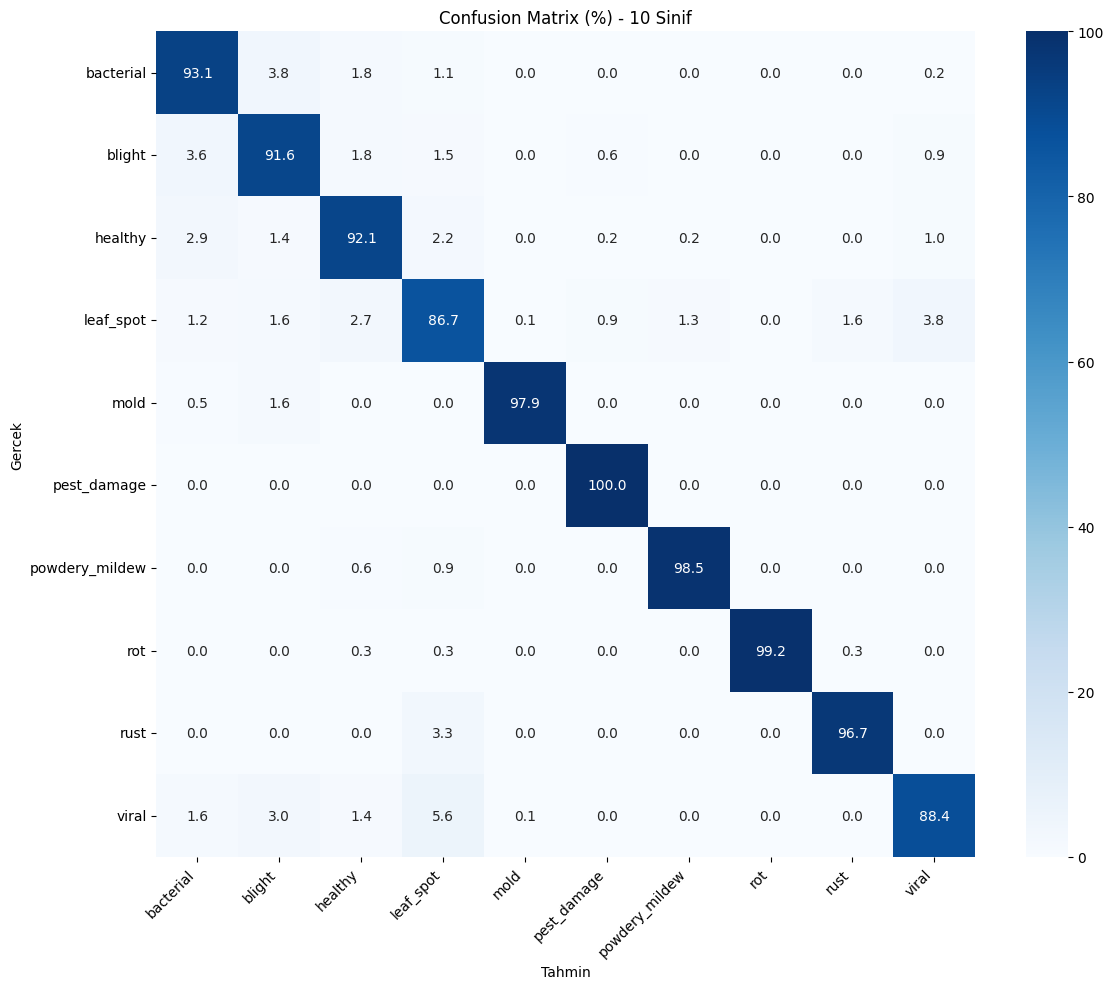

Kaydedildi.


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import confusion_matrix

model = tf.keras.models.load_model(MODEL_PATH)

y_true_cm, y_pred_cm = [], []

for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_true_cm.extend(labels.numpy())
    y_pred_cm.extend(np.argmax(preds, axis=1))

y_true_cm = np.array(y_true_cm)
y_pred_cm = np.array(y_pred_cm)

cm = confusion_matrix(y_true_cm, y_pred_cm)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=DISEASE_CLASSES,
    yticklabels=DISEASE_CLASSES
)

plt.title("Confusion Matrix (%) - 10 Sinif")
plt.ylabel("Gercek")
plt.xlabel("Tahmin")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(str(OUTPUTS_DIR / "confusion_matrix_10class.png"), dpi=150)
plt.show()

print("Kaydedildi.")